## J-magnitude threshold + **Test** of **U-Net model** on real data

In [1]:
!hostname

mtx37


In [3]:
import gelsa
from gelsa.sgs import datastore
from matplotlib import pyplot as plt
from gelsa import visu
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Rescaling

In [4]:
print(gelsa.__version__)

3.1


In [5]:
gpu=1
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    tf.config.set_visible_devices(gpus[gpu], 'GPU')
    logical_gpus = tf.config.list_logical_devices('GPU')
    print("Using GPU number {}".format(gpu))
  except RuntimeError as e:
    print(e)
else:
    print("GPU not found")

GPU not found


In [6]:
pt_id = 30399

In [7]:
DS = datastore.DataStore(username='', password='',
                        cachedir='/scratch/astro/benjamin.granett/datastore'
                        )


# Load the data related to the pointing_id
file_list = DS.load_sir_pack("DR1_R1", pointing_id_list=[pt_id])
# Create a Gelsa object
G = gelsa.Gelsa(config_file="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/gelsa_config.json", 
                calibdir="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/", zero_order_catalog=None)
# Define the frame associated to the pointing
frame = G.load_spec_frame(**file_list[0])

got username `` and password ***
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30399, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30399'
got len(path_hits)=2
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml


In [8]:
import astroquery 
from astroquery.vizier import Vizier
from astropy.table import Table
import astropy.coordinates as coord
import astropy.units as u

In [9]:
pointing_filename = "/scratch/astro/nicolo.fiaba/pointing_list.txt"
pointings = Table.read(pointing_filename, format='ascii')

In [10]:
# 2-mass catalog. Do we need this?
vizier = Vizier()
vizier.ROW_LIMIT = 1e6

In [11]:
pt_id_num = np.where(pointings["Data.ObservationSequence.PointingId"] == pt_id)[0][0]

In [12]:
grism = pointings["Data.Grism"][pt_id_num]
grism_tilt = pointings["Data.GrismWheelTilt"][pt_id_num]
print(grism, grism_tilt)

RGS180 4.0


In [13]:
pt_ra = pointings["Data.AdjustedPointing.RA"][pt_id_num]
pt_dec = pointings["Data.AdjustedPointing.Dec"][pt_id_num]

In [14]:
result = vizier.query_region(coord.SkyCoord(ra=pt_ra, dec=pt_dec,
                                            unit=(u.deg, u.deg),
                                            frame='icrs'),
                        width='0.763deg',
                        height='0.722deg',
                        catalog="II/246/out")

data_2mass = result[0]

In [15]:
# print(np.argsort(data_2mass['Jmag']))
sorted_data = data_2mass[np.argsort(data_2mass['Jmag'])]

In [16]:
mn = 35

x1, y1, det1 = frame.radec_to_pixel(sorted_data[mn:]['RAJ2000'], 
                                    sorted_data[mn:]['DEJ2000'], 
                                    wavelength=12000)
x2, y2, det2 = frame.radec_to_pixel(sorted_data[mn:]['RAJ2000'], 
                                    sorted_data[mn:]['DEJ2000'], 
                                    wavelength=19000)

In [17]:
first_eq_mask = (det1 == det2) & (det1 != -1) & (det2 != -1)

detect = det1[first_eq_mask][0]
index = np.where(first_eq_mask)[0][0]

print("detector:", detect, "\nIndex:", index)

detector: 13 
Index: 3


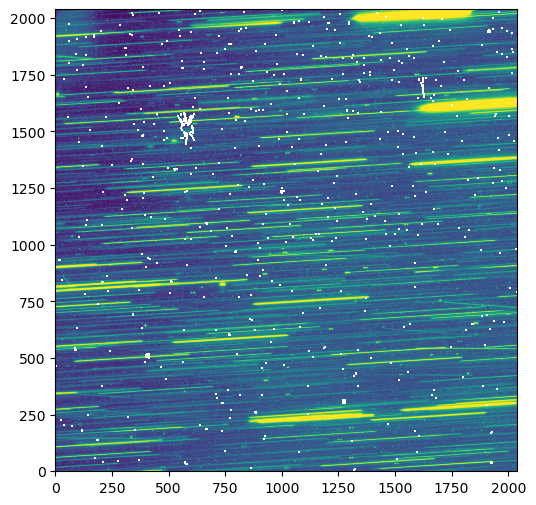

In [18]:
img, mask, var = frame.get_detector(0)
# img[mask > 0] = np.nan
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(visu.normalize_image(img, levels=(5, 95)), origin='lower', aspect=1)
# ax.scatter(x1[index], y1[index], marker='<', c='red')
# ax.scatter(x2[index], y2[index], marker='>', c='red')
# plt.savefig("img_pt30399_mask.png")
# plt.xlim(0, 512)
# plt.ylim(0, 512)

In [19]:
msks = []
for d in range(16):
    im, msk, vr = frame.get_detector(d)
    msks.append(msk)

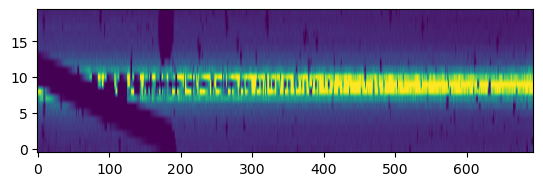

In [20]:
im, var, norm, pix_bins = frame.resample_on_wavelength(sorted_data[mn + index]['RAJ2000'],
                                                       sorted_data[mn + index]['DEJ2000'],
                                                       wave_range=frame.params['wavelength_range'],
                                                       super_sample=1,
                                                       extraction_window_pix = 20
                                                      )
plt.imshow(visu.normalize_image(im, levels=(5, 95)), origin='lower', aspect=10)

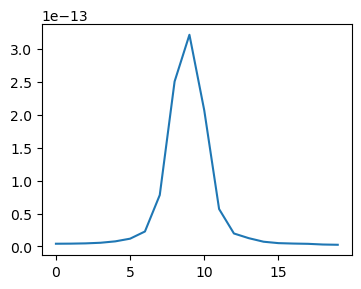

In [21]:
fig = plt.figure(figsize=(4,3))
plt.plot(im.sum(axis=1))

In [22]:
jmag_threshold = sorted_data['Jmag'][35]
print("The chosen threshold for Jmag is", jmag_threshold)

The chosen threshold for Jmag is 11.506


END of test

---

## **Testing** U-Net on real data

In [23]:
"""
frame = G.new_spec_frame(ra=200, dec=0, pa=0)
"""

'\nframe = G.new_spec_frame(ra=200, dec=0, pa=0)\n'

In [24]:
ra_el, dec_el = frame.pixel_to_radec(x=102, y=30, det=0, wavelength=15500)

In [25]:
ra_el, dec_el

(267.414248894465, 66.35219891236521)

In [26]:
from astropy.constants import c
J_0 = 1594
H_0 = 1024
K_0 = 666.7
j_center =  13673
c_cgs = c.cgs.value
factor = lambda lam: (c_cgs*1e8)/(lam**2)

mag = 2

mag_to_flux = lambda m, f_0: f_0 * 10**(- m / 2.5)

flux_el_J = mag_to_flux(mag, J_0) * 1e-23 #specific flux in Jy * 10^-23 = specific flux in cgs

flux_j_lam = flux_el_J * factor(j_center)

log_j_flux = np.log10(flux_j_lam)


#### $\rightarrow$ Add a simulated emission line 

In [27]:
continuum_wavelength = np.linspace(12000, 19000, 100)

In [28]:
from astropy.modeling.models import Gaussian1D

amp = 3
sigma = 200

g = Gaussian1D(amplitude=amp, mean=15500, stddev=sigma)
gauss_emission_line = g(continuum_wavelength)
flux = np.ones(100)*-18 + gauss_emission_line

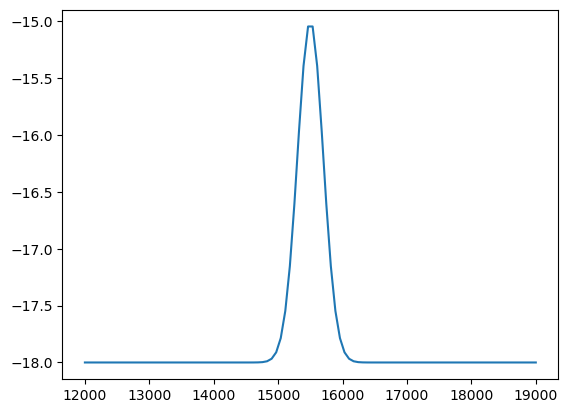

In [29]:
plt.plot(continuum_wavelength, flux)

In [30]:
continuum_flux = 10**(flux)

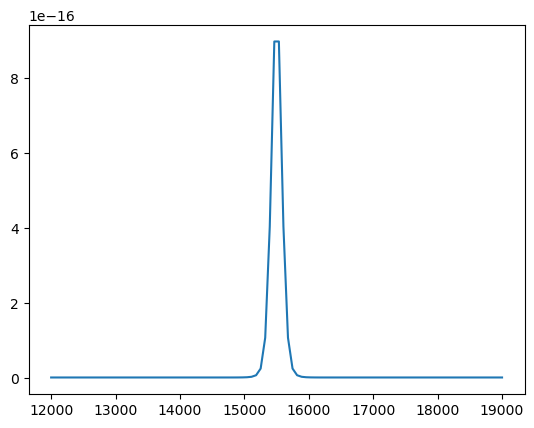

In [31]:
plt.plot(continuum_wavelength, continuum_flux)

In [32]:
from gelsa import galaxy

sim_el = galaxy.Galaxy(
                ra=ra_el,
                dec=dec_el,
                redshift=0,
                fwhm_arcsec=1,
                axis_ratio=1,
                continuum_params=(15000, -1e-5, -17),
                obs_wavelength_range=(12000, 19000)
                )
sim_el.set_sed(continuum_wavelength, continuum_flux)

frame.add_sources([sim_el], noise=False)

In [33]:
img, mask, var = frame.get_detector(0)

In [34]:
np.nanmax(img)

2308919.8

(0.0, 250.0)

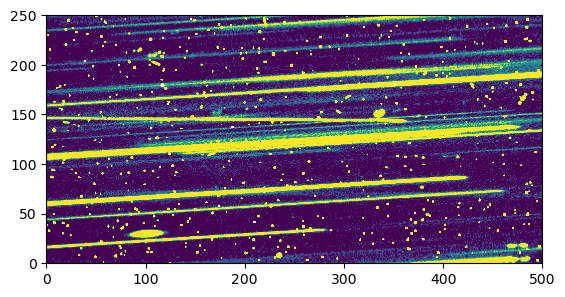

In [35]:
plt.imshow(img, origin='lower', aspect=1, vmin=0, vmax=500)
# plt.scatter(102, 75, c='red', marker='x', alpha=0.5)
plt.xlim(0, 500)
plt.ylim(0, 250)

# Testing the Att.UNET model on Real Data

In [20]:
img_nomask = img.copy()
mask = np.isnan(img_nomask).astype(np.float32)

x_max = np.nanmax(img_nomask)
x_min = np.nanmin(img_nomask)
rescale = Rescaling(1./(x_max - x_min), offset=-x_min/(x_max - x_min), input_shape=(512, 512, 1))

In [21]:
scaled = rescale(img_nomask)

In [22]:
input_imgs = np.stack([scaled, mask], axis=-1)

In [23]:
# adapted from https://github.com/obss/sahi/blob/e798c80d6e09079ae07a672c89732dd602fe9001/sahi/slicing.py#L30, MIT License
def calculate_slice_bboxes(
    image_height: int = 2040,
    image_width: int = 2040,
    slice_height: int = 512,
    slice_width: int = 512,
    overlap_height_ratio: float = 0.1,
    overlap_width_ratio: float = 0.1,
) -> list[list[int]]:
    """
    Given the height and width of an image, calculates how to divide the image into
    overlapping slices according to the height and width provided. These slices are returned
    as bounding boxes in xyxy format.
    :param image_height: Height of the original image.
    :param image_width: Width of the original image.
    :param slice_height: Height of each slice
    :param slice_width: Width of each slice
    :param overlap_height_ratio: Fractional overlap in height of each slice (e.g. an overlap of 0.2 for a slice of size 100 yields an overlap of 20 pixels)
    :param overlap_width_ratio: Fractional overlap in width of each slice (e.g. an overlap of 0.2 for a slice of size 100 yields an overlap of 20 pixels)
    :return: a list of bounding boxes in xyxy format
    """

    slice_bboxes = []
    y_max = y_min = 0
    y_overlap = int(overlap_height_ratio * slice_height)
    x_overlap = int(overlap_width_ratio * slice_width)
    while y_max < image_height:
        x_min = x_max = 0
        y_max = y_min + slice_height
        while x_max < image_width:
            x_max = x_min + slice_width
            if y_max > image_height or x_max > image_width:
                xmax = min(image_width, x_max)
                ymax = min(image_height, y_max)
                xmin = max(0, xmax - slice_width)
                ymin = max(0, ymax - slice_height)
                slice_bboxes.append([xmin, ymin, xmax, ymax])
            else:
                slice_bboxes.append([x_min, y_min, x_max, y_max])
            x_min = x_max - x_overlap
        y_min = y_max - y_overlap
    return slice_bboxes

In [24]:
slices = calculate_slice_bboxes()
slices = np.array(slices)

In [25]:
def create_patches(image, slices):
    patches = []
    for ind in range(len(slices)): # Loop over the patches (rows of slices)
        xmin, ymin, xmax, ymax = slices[ind]
        cropped = image[ymin:ymax, xmin:xmax]
        patches.append(cropped)
    patches = np.array(patches)
    return patches

In [26]:
patches = create_patches(input_imgs, slices)
print(patches.shape)


(25, 512, 512, 2)


In [27]:
test_img = tf.where(tf.math.is_nan(patches), 0., patches)

In [28]:
test_img.shape

TensorShape([25, 512, 512, 2])

In [40]:
from keras.models import load_model
saved_model = load_model('/scratch/astro/nicolo.fiaba/trained_models/denoise_attention_unet_model_RGS180_4.h5', compile=False)

saved_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='mse',
                  metrics="mse")

In [31]:
nan_count = np.isnan(test_img).sum()
print(nan_count, "NaN pixels need to be set to 0")

0 NaN pixels need to be set to 0


In [41]:
pred_trained = saved_model.predict(test_img)

1/1 [==============================] - 9s 9s/step


In [42]:
pred_trained = np.squeeze(pred_trained)
pred_trained.shape

(25, 512, 512)

In [34]:
test_img[...,0].shape

TensorShape([25, 512, 512])

0


Text(0.5, 0.98, 'Index: 0')

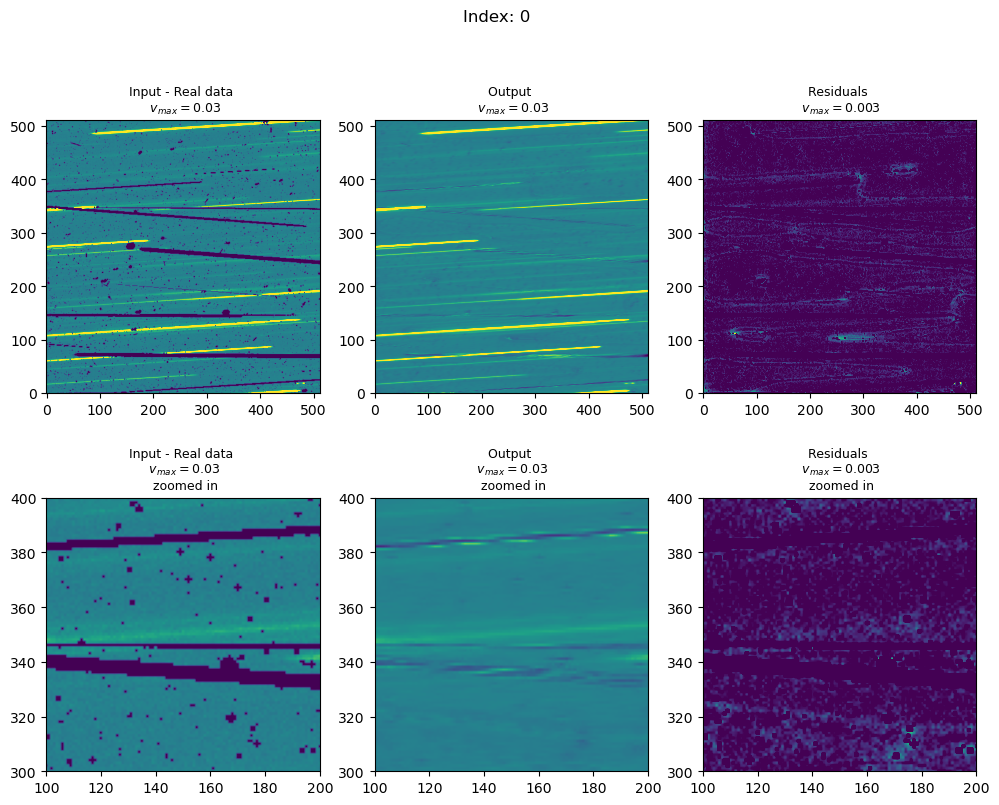

In [62]:
index = 0
print(index)

fig, axs = plt.subplots(2, 3, figsize=(12,9))
lis = [test_img[...,0], pred_trained, test_img[...,0]-pred_trained]
titles = ['Input - Real data \n $v_{max} = 0.03$', 'Output \n $v_{max} = 0.03$', 'Residuals \n $v_{max} = 0.003$']
vmax_s = [0.02, 0.02, 0.003]

for i, ax in enumerate(axs.flatten()[:3]):
    ax.imshow(lis[i][index], aspect=1, origin='lower', vmin=0, vmax=vmax_s[i])
    ax.set_title(titles[i], fontsize=9)
    # ax.set_xlim(300, 400)
    # ax.set_ylim(400, 500)

uncolored_circle = plt.Circle((333, 447 ), 10, fill = False, color='white', label='Emission line?')

for i, ax in enumerate(axs.flatten()[3:]):
    ax.imshow(lis[i][index], aspect=1, vmin=0, vmax=vmax_s[i], origin='lower')
    ax.set_title(titles[i]+' \n zoomed in', fontsize=9)
    ax.set_xlim(100, 200)
    ax.set_ylim(300, 400)

# axs.flatten()[-1].add_artist(uncolored_circle)
plt.suptitle("Index: {}".format(index))
# plt.legend()
# plt.savefig('images/att_UNET_test_realdata.png')

In [51]:
flatten_diff = tf.reshape(test_img[...,0][index]-pred_trained[index], [-1])

(array([3.3800e+02, 3.6100e+02, 4.1500e+02, 6.1700e+02, 8.1700e+02,
        1.1320e+03, 1.4370e+03, 1.5290e+03, 1.3450e+03, 1.0340e+03,
        7.9400e+02, 6.2500e+02, 5.4900e+02, 4.1400e+02, 3.1400e+02,
        2.3600e+02, 1.7000e+02, 1.3400e+02, 1.0900e+02, 7.9000e+01,
        7.5000e+01, 6.8000e+01, 5.3000e+01, 3.1000e+01, 2.9000e+01,
        2.8000e+01, 1.7000e+01, 2.6000e+01, 2.0000e+01, 1.6000e+01,
        1.7000e+01, 2.0000e+01, 2.1000e+01, 1.8000e+01, 1.9000e+01,
        1.1000e+01, 1.2000e+01, 1.8000e+01, 2.0000e+01, 3.1000e+01,
        3.7000e+01, 5.5000e+01, 8.3000e+01, 1.4700e+02, 4.6400e+02,
        2.1230e+03, 8.9320e+03, 2.6130e+04, 4.9686e+04, 6.0198e+04,
        4.8440e+04, 2.8310e+04, 1.3181e+04, 5.4250e+03, 2.2150e+03,
        8.6500e+02, 4.6300e+02, 2.2800e+02, 1.1400e+02, 7.7000e+01,
        5.9000e+01, 2.9000e+01, 2.3000e+01, 2.7000e+01, 1.4000e+01,
        8.0000e+00, 1.4000e+01, 7.0000e+00, 7.0000e+00, 6.0000e+00,
        6.0000e+00, 3.0000e+00, 3.0000e+00, 4.00

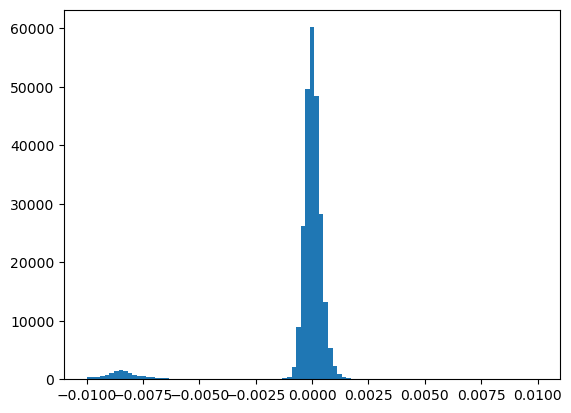

In [52]:
plt.hist(flatten_diff, bins=np.linspace(-0.01, 0.01, 100))